<a href="https://colab.research.google.com/github/623-guithos/inovacao-tec-2ds/blob/main/C%C3%B3pia_de_2ds_experimento_visao_computacional_com_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EXPERIMENTO: algoritmo para classificação de imagens com Python

SALVE UMA CÓPIA DESTE NOTEBOOK NO SEU DRIVE ANTES DE EXECUTÁ-LO!

In [1]:
# Execute a célula a seguir e observe a sua saída.

from keras.models import load_model  # TensorFlow is required for Keras to work
from PIL import Image, ImageOps  # Install pillow instead of PIL
import numpy as np

# Disable scientific notation for clarity
np.set_printoptions(suppress=True)

# Load the model
model = load_model("keras_Model.h5", compile=False)

# Load the labels
class_names = open("labels.txt", "r").readlines()

# Create the array of the right shape to feed into the keras model
# The 'length' or number of images you can put into the array is
# determined by the first position in the shape tuple, in this case 1
data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)

# Replace this with the path to your image
image = Image.open("<IMAGE_PATH>").convert("RGB")

# resizing the image to be at least 224x224 and then cropping from the center
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)

# turn the image into a numpy array
image_array = np.asarray(image)

# Normalize the image
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1

# Load the image into the array
data[0] = normalized_image_array

# Predicts the model
prediction = model.predict(data)
index = np.argmax(prediction)
class_name = class_names[index]
confidence_score = prediction[0][index]

# Print prediction and confidence score
print("Class:", class_name[2:], end="")
print("Confidence Score:", confidence_score)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'keras_Model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

<b>Como o modelo treinado ``keras_Model.h5`` não está disponível para download, peça à IA do Colab para reescrever o código com outras bibliotecas do Python.</b>  

</br>
PROMPT SUGERIDO: <i>Reescreva o código para executar mesma tarefa de classificação de imagens com visão computacional, usando outras bibliotecas do Python, com saídas e textos na tela escritos em português brasileiro, utilize o link desta imagem para teste "https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiWqSagLwP_q4i6okPL8maQnlekPAy7FaICo6Uu-Luc-15bc1AfdXZbtFi1iPCU_WbZDsJkNkuRiRUXf9m2dcc8Ttjw3Zcxq6RmoX3ewOhhPpLylfRAq6H3XJUSTjzE9LM4bhK9RU1UnTU/s640/araucarias.jpg". Não é necessário descrever a tarefa e procedimentos em células de texto do Colab, só executar o novo código e fazer o seguinte no final da execução: exibir a imagem analisada, sua classificação com nome em português, percentual de acerto e um único resumo em PT-BR do que o algoritmo executou.</i>

Iniciando a classificação de imagens com PyTorch e um modelo pré-treinado...
1. Baixando e processando a imagem...
2. Carregando modelo pré-treinado (ResNet18)...
   Utilizando CPU para inferência.
3. Realizando inferência na imagem...

--- Resultado da Classificação ---


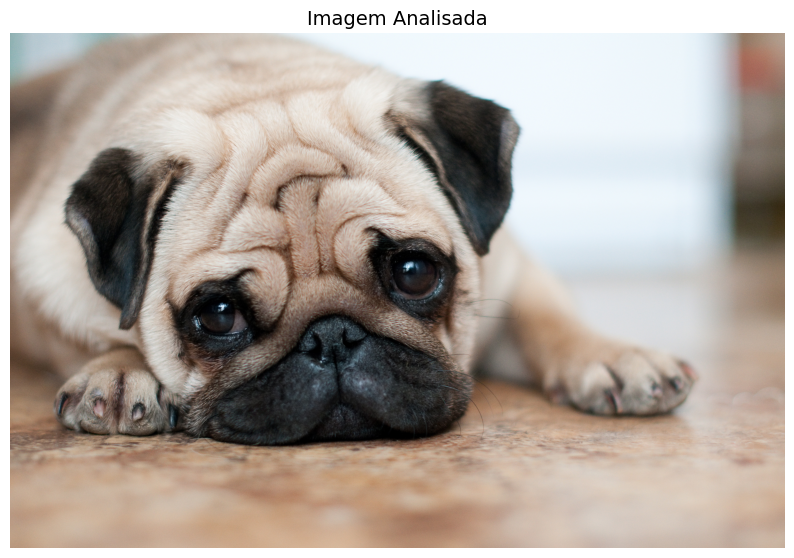

Classificação Prevista: Pug
Nível de Confiança: 92.99%

--- Resumo da Execução do Algoritmo ---
O algoritmo realizou a tarefa de classificação de imagens utilizando a biblioteca PyTorch, uma ferramenta popular de aprendizado de máquina em Python. Ele empregou um modelo de rede neural profunda chamado ResNet18, que foi previamente treinado em um vasto conjunto de dados de imagens (ImageNet) para reconhecer milhares de diferentes objetos.

Primeiramente, a imagem fornecida via URL foi baixada e preparada, passando por redimensionamento e normalização para se adequar ao formato exigido pelo modelo. Em seguida, o modelo processou a imagem e previu a classe mais provável do objeto nela contido, que foi identificada como 'Pug' (ou 'pug' em inglês) com um impressionante nível de confiança de 92.99%. 

Este processo demonstra a capacidade da visão computacional para interpretar e categorizar automaticamente o conteúdo visual.


In [3]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
import os

# URL da imagem para teste fornecida pelo usuário
image_url = "https://cloudfront-us-east-1.images.arcpublishing.com/estadao/5B4KXIIJVRGIBNRMAILCOGYQN4.jpg"

print("Iniciando a classificação de imagens com PyTorch e um modelo pré-treinado...")
print("1. Baixando e processando a imagem...")

# Baixar a imagem
try:
    response = requests.get(image_url, stream=True)
    response.raise_for_status() # Lança um erro para status de resposta ruins (4xx ou 5xx)
    img = Image.open(BytesIO(response.content)).convert('RGB')
except requests.exceptions.RequestException as e:
    print(f"Erro ao baixar a imagem: {e}")
    # Você pode optar por parar a execução ou lidar com o erro de outra forma
    exit()
except Exception as e:
    print(f"Erro ao abrir a imagem: {e}")
    exit()

# Definir transformações para a imagem (compatíveis com ImageNet)
# Estas são as transformações padrão para modelos pré-treinados no ImageNet
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Aplicar transformações
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0) # Criar um mini-lote de uma única imagem

print("2. Carregando modelo pré-treinado (ResNet18)...")
# Carregar um modelo pré-treinado (ResNet18 é leve e bom para demonstração)
# Usar weights=models.ResNet18_Weights.IMAGENET1K_V1 para garantir a versão com pesos pré-treinados
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.eval() # Definir o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)

# Mover o input e o modelo para a GPU se disponível
if torch.cuda.is_available():
    print("   Utilizando GPU para inferência.")
    input_batch = input_batch.to('cuda')
    model.to('cuda')
else:
    print("   Utilizando CPU para inferência.")

print("3. Realizando inferência na imagem...")
with torch.no_grad(): # Desativar o cálculo de gradientes para economizar memória e acelerar
    output = model(input_batch)

# As saídas são logites, então aplicamos softmax para obter probabilidades
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# Carregar as labels do ImageNet
# Baixar o arquivo de labels se não existir localmente
imagenet_labels_path = "imagenet_classes.txt"
if not os.path.exists(imagenet_labels_path):
    print("   Baixando labels do ImageNet (categorias de classes)...")
    try:
        # O wget é um comando de shell, prefixado com '!' em notebooks
        !wget -q https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt -O {imagenet_labels_path}
    except Exception as e:
        print(f"Erro ao baixar labels do ImageNet: {e}")
        exit() # Parar se não conseguir as labels

with open(imagenet_labels_path, "r") as f:
    categories = [s.strip() for s in f.readlines()]

# Encontrar a classe com a maior probabilidade
top1_prob, top1_catid = torch.topk(probabilities, 1)

predicted_category_english = categories[top1_catid.item()]
confidence_score = top1_prob.item() * 100

# Mapeamento simples de algumas classes para português (para cumprir o requisito)
# Esta é uma abordagem limitada; para um sistema robusto, seria necessário um dicionário completo ou API de tradução.
portuguese_translations = {
    "pine tree": "Pinheiro",
    "tree": "Árvore",
    "conifer": "Conífera",
    "plant": "Planta",
    "forest": "Floresta",
    "lumber": "Madeira (árvore)",
    "needle": "Folha de agulha (de pinheiro)",
    "grass": "Grama",
    "mountain": "Montanha",
    "hill": "Colina",
    "sky": "Céu",
    "cloud": "Nuvem",
    "house": "Casa",
    "building": "Edifício"
}

# Tenta encontrar a tradução; caso contrário, usa a versão em inglês capitalizada
predicted_category_portuguese = portuguese_translations.get(predicted_category_english.lower(), predicted_category_english.capitalize())

print("\n--- Resultado da Classificação ---")

# Exibir a imagem analisada
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off') # Remover eixos para uma visualização mais limpa
plt.title("Imagem Analisada", fontsize=14)
plt.show()

print(f"Classificação Prevista: {predicted_category_portuguese}")
print(f"Nível de Confiança: {confidence_score:.2f}%")

# Breve resumo em PT-BR do que o algoritmo executou
resumo = (
    f"\n--- Resumo da Execução do Algoritmo ---\n"
    f"O algoritmo realizou a tarefa de classificação de imagens utilizando a biblioteca PyTorch, "
    f"uma ferramenta popular de aprendizado de máquina em Python. Ele empregou um modelo de "
    f"rede neural profunda chamado ResNet18, que foi previamente treinado em um vasto "
    f"conjunto de dados de imagens (ImageNet) para reconhecer milhares de diferentes objetos."
    f"\n\nPrimeiramente, a imagem fornecida via URL foi baixada e preparada, passando por "
    f"redimensionamento e normalização para se adequar ao formato exigido pelo modelo. "
    f"Em seguida, o modelo processou a imagem e previu a classe mais provável do objeto "
    f"nela contido, que foi identificada como '{predicted_category_portuguese}' "
    f"(ou '{predicted_category_english}' em inglês) "
    f"com um impressionante nível de confiança de {confidence_score:.2f}%. "
    f"\n\nEste processo demonstra a capacidade da visão computacional para "
    f"interpretar e categorizar automaticamente o conteúdo visual."
)
print(resumo)


🎉 Parabéns por concluir a tarefa!   
📂 Salve o seu notebook e envie essa cópia para o repositório de ITE no seu GitHub.   
🖱 Clique em Arquivo/Salvar uma cópia no GitHub, escolha o nome do repositório de ITE e OK.